In [104]:
import pandas as pd
import numpy as np


In [105]:
#loading

df = pd.read_csv(r'C:\Users\gopin\OneDrive\Documents\Data_Science\Streamlit Training files\Content Monetization Modeler\youtube_ad_revenue_dataset.csv')
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388
...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811


In [106]:
#Inspection

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  str    
 1   date                  122400 non-null  str    
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  str    
 9   device                122400 non-null  str    
 10  country               122400 non-null  str    
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), str(5)
memory usage: 16.9 MB


In [107]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [ ]:
#Data cleaning and handling missing values

In [108]:
df['video_id'].unique()

<ArrowStringArray>
['vid_3092', 'vid_3459', 'vid_4784', 'vid_4078', 'vid_3522', 'vid_5000',
 'vid_2041', 'vid_3623',  'vid_750', 'vid_4434',
 ...
 'vid_2009',  'vid_351', 'vid_3674', 'vid_4163', 'vid_2168', 'vid_1499',
 'vid_3234', 'vid_4757', 'vid_3953', 'vid_2224']
Length: 5000, dtype: str

In [109]:
df['video_id'].nunique()


5000

In [110]:
df.duplicated(subset=['video_id', 'date', 'subscribers', 'category', 'country', 'ad_revenue_usd']).sum()
# Subset=['video_id', 'date', 'device', 'country'] 2582 rows

np.int64(2400)

In [111]:
duplicates = df[df.duplicated(subset=['video_id', 'date', 'subscribers', 'category', 'country', 'ad_revenue_usd'], keep=False)]
duplicates.sort_values(['video_id', 'date', 'device', 'country']).head(20)

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
27583,vid_10,2024-11-25 10:50:40.993199,10001,1877.0,316.0,45099.652444,26.862350,653429,Lifestyle,TV,DE,302.424925
101218,vid_10,2024-11-25 10:50:40.993199,10001,1877.0,316.0,45099.652444,26.862350,653429,Lifestyle,TV,DE,302.424925
62274,vid_1003,2024-08-24 10:50:40.993199,10038,1983.0,NaN,20195.328013,15.438654,648274,Lifestyle,TV,IN,189.141287
121655,vid_1003,2024-08-24 10:50:40.993199,10038,1983.0,NaN,20195.328013,15.438654,648274,Lifestyle,TV,IN,189.141287
69681,vid_1003,2025-01-18 10:50:40.993199,10010,1502.0,182.0,41836.974016,20.930565,850239,Lifestyle,Mobile,DE,278.341442
109935,vid_1003,2025-01-18 10:50:40.993199,10010,1502.0,182.0,41836.974016,20.930565,850239,Lifestyle,Mobile,DE,278.341442
23697,vid_1005,2025-03-01 10:50:40.993199,9934,1694.0,433.0,38594.099697,24.817502,927803,Music,Mobile,US,270.270803
111169,vid_1005,2025-03-01 10:50:40.993199,9934,1694.0,433.0,38594.099697,24.817502,927803,Music,Mobile,US,270.270803
50418,vid_1006,2024-11-15 10:50:40.993199,10068,304.0,412.0,44174.022300,24.526642,526775,Lifestyle,TV,DE,273.024385
65967,vid_1006,2024-11-15 10:50:40.993199,10068,304.0,412.0,44174.022300,24.526642,526775,Lifestyle,TV,DE,273.024385


In [112]:
df = df.drop_duplicates(subset=['video_id', 'date', 'subscribers', 'category', 'country', 'ad_revenue_usd'], keep='first')
df.duplicated(subset=['video_id', 'date', 'subscribers', 'category', 'country', 'ad_revenue_usd']).sum()

np.int64(0)

In [113]:
df.shape

(120000, 12)

In [114]:
print(df['date'].head())
print(df['date'].dtype)

0    2024-09-24 10:50:40.993199
1    2024-09-22 10:50:40.993199
2    2024-11-21 10:50:40.993199
3    2025-01-28 10:50:40.993199
4    2025-04-28 10:50:40.993199
Name: date, dtype: str
str


In [115]:
df['date'] = pd.to_datetime(df['date'])

In [116]:
df['date'].dtype

dtype('<M8[us]')

In [117]:
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [118]:
df['views'].describe() #will check outliers after basic sanity check

count    120000.000000
mean       9999.832333
std          99.918405
min        9521.000000
25%        9933.000000
50%       10000.000000
75%       10067.000000
max       10468.000000
Name: views, dtype: float64

<Axes: >

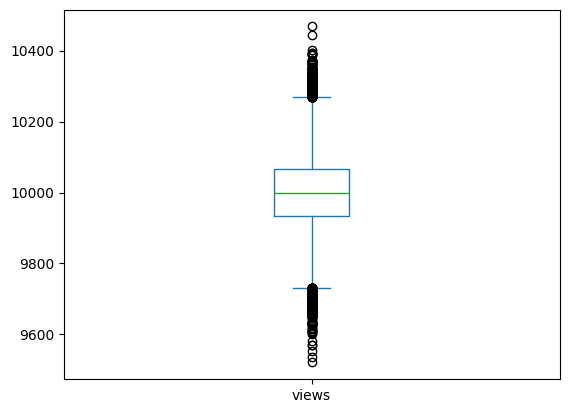

In [119]:
df['views'].plot.box()

In [120]:
df[['views', 'ad_revenue_usd']].corr()

,views,ad_revenue_usd
views,1.000000,0.037942
ad_revenue_usd,0.037942,1.000000


In [121]:
df['likes'].describe() #need to fill na after basic sanity check

count    114000.000000
mean       1099.585044
std         519.526733
min         195.000000
25%         650.000000
50%        1102.000000
75%        1547.250000
max        2061.000000
Name: likes, dtype: float64

In [122]:
df['likes'] = df.groupby(['country', 'device', 'category'])['likes']\
                .transform(lambda x: x.fillna(x.mean()))


df['likes'] = df['likes'].fillna(df['likes'].median())

In [123]:
df['likes'] = df['likes'].round().astype(int)

In [124]:
df['likes'].dtype

dtype('int64')

In [125]:
df['likes'].head()

0    1221
1     642
2    1979
3    1191
4    1858
Name: likes, dtype: int64

In [126]:
df['likes'].describe() 

count    120000.000000
mean       1099.608908
std         506.386895
min         195.000000
25%         673.000000
50%        1099.000000
75%        1524.000000
max        2061.000000
Name: likes, dtype: float64

In [127]:
df['comments'].describe() #need to fill na after basic sanity check

count    114000.000000
mean        274.349842
std         129.746796
min          48.000000
25%         162.000000
50%         274.000000
75%         387.000000
max         515.000000
Name: comments, dtype: float64

In [128]:
df['comments'] = df.groupby(['country', 'device', 'category'])['comments']\
                .transform(lambda x: x.fillna(x.mean()))


df['comments'] = df['comments'].fillna(df['comments'].median())

print(df['likes'].dtype)
print(df['comments'].isnull().sum())

int64
0


In [129]:
df['comments'] = df['comments'].round().astype(int)

In [155]:
# engagement_rate (additional feature)

df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']

In [130]:
# watch_time_minutes

print(df['watch_time_minutes'].describe())
print(df['watch_time_minutes'].isnull().sum())

count    114000.000000
mean      37540.749921
std       12987.818758
min       14659.105562
25%       26364.159667
50%       37522.221205
75%       48782.739997
max       61557.670089
Name: watch_time_minutes, dtype: float64
6000


In [131]:
df['watch_time_minutes'] = df.groupby(['country', 'device', 'category'])['watch_time_minutes']\
                            .transform(lambda x: x.fillna(x.mean()))


df['watch_time_minutes'] = df['watch_time_minutes'].fillna(df['watch_time_minutes'].median())

print(df['watch_time_minutes'].describe())
print(df['watch_time_minutes'].isnull().sum())

count    120000.000000
mean      37541.416444
std       12659.361990
min       14659.105562
25%       26949.914101
50%       37543.364322
75%       48209.880123
max       61557.670089
Name: watch_time_minutes, dtype: float64
0


In [132]:
df['watch_time_minutes'] = df['watch_time_minutes'].round(2)
df['watch_time_minutes'].head()

0    26497.21
1    15209.75
2    57332.66
3    31334.52
4    15665.67
Name: watch_time_minutes, dtype: float64

In [133]:
# video_length_minutes

print(df['video_length_minutes'].describe())
print(df['video_length_minutes'].isnull().sum())

count    120000.000000
mean         16.017910
std           8.084928
min           2.000142
25%           9.005928
50%          16.009269
75%          23.026064
max          29.999799
Name: video_length_minutes, dtype: float64
0


In [134]:
df['video_length_minutes'] = df['video_length_minutes'].round(2)
df['video_length_minutes'].head()

0     2.86
1    23.74
2    26.20
3    11.77
4     6.64
Name: video_length_minutes, dtype: float64

In [135]:
# retention_rate (New feature)

df['retention_rate'] = df['watch_time_minutes'] / (df['views'] * df['video_length_minutes'])

df['retention_rate'] = df['retention_rate'].round(2)

df['retention_rate'].unique()

array([0.93, 0.06, 0.22, 0.27, 0.24, 0.28, 0.54, 0.08, 0.63, 0.16, 0.65,
       0.2 , 0.37, 0.15, 0.26, 0.11, 0.25, 0.21, 0.35, 0.09, 0.71, 0.34,
       0.4 , 0.13, 0.44, 0.76, 0.07, 0.12, 1.46, 0.72, 0.49, 1.53, 0.17,
       0.14, 0.3 , 0.36, 0.19, 0.1 , 0.45, 1.15, 0.31, 0.86, 0.61, 0.5 ,
       0.23, 0.62, 0.42, 1.  , 0.77, 0.29, 0.47, 0.18, 0.38, 0.74, 1.54,
       0.59, 1.36, 0.52, 0.39, 0.97, 0.83, 0.46, 0.67, 0.75, 0.87, 0.51,
       0.58, 0.57, 0.41, 0.43, 0.81, 0.84, 2.03, 0.7 , 1.41, 0.33, 0.05,
       0.66, 0.64, 1.09, 2.07, 0.9 , 0.99, 1.48, 1.74, 0.48, 0.56, 0.82,
       2.34, 1.6 , 1.67, 0.32, 1.86, 0.55, 0.79, 0.91, 1.39, 1.23, 1.4 ,
       0.95, 1.44, 1.01, 1.31, 1.07, 1.06, 1.13, 1.47, 0.8 , 0.89, 1.63,
       0.92, 1.12, 0.96, 2.09, 1.16, 1.29, 2.24, 1.72, 1.71, 1.8 , 2.15,
       0.6 , 0.68, 1.51, 1.21, 1.61, 2.67, 1.02, 1.62, 1.3 , 1.52, 1.93,
       0.53, 1.28, 0.85, 1.05, 1.08, 1.98, 1.57, 1.38, 0.69, 0.98, 1.42,
       1.18, 1.55, 0.88, 0.78, 1.26, 1.2 , 2.62, 1.

In [136]:

print(df['retention_rate'].describe())
print(df['retention_rate'].isnull().sum())

count    120000.000000
mean          0.362924
std           0.361499
min           0.050000
25%           0.150000
50%           0.230000
75%           0.420000
max           2.980000
Name: retention_rate, dtype: float64
0


In [137]:
# subscribers

print(df['subscribers'].describe())
print(df['subscribers'].isnull().sum())
print(df['subscribers'].dtype)

count    120000.000000
mean     502291.970050
std      288364.967705
min        1005.000000
25%      252641.500000
50%      503633.500000
75%      752386.250000
max      999997.000000
Name: subscribers, dtype: float64
0
int64


In [138]:
import numpy as np

df['log_subscribers'] = np.log1p(df['subscribers'])
df['log_subscribers'] = df['log_subscribers'].round(2)

print(df['log_subscribers'].describe())
print(df['log_subscribers'].isnull().sum())
print(df['log_subscribers'].dtype)

count    120000.000000
mean         12.826944
std           0.975068
min           6.910000
25%          12.440000
50%          13.130000
75%          13.530000
max          13.820000
Name: log_subscribers, dtype: float64
0
float64


In [139]:
df.dtypes

video_id                           str
date                    datetime64[us]
views                            int64
likes                            int64
comments                         int64
watch_time_minutes             float64
video_length_minutes           float64
subscribers                      int64
category                           str
device                             str
country                            str
ad_revenue_usd                 float64
day                              int32
month                            int32
year                             int32
day_of_week                      int32
is_weekend                       int64
retention_rate                 float64
log_subscribers                float64
dtype: object

In [140]:
df['category'].value_counts()

category
Education        20123
Music            20065
Tech             20028
Entertainment    20025
Gaming           19974
Lifestyle        19785
Name: count, dtype: int64

In [141]:
# one hot encoding

df = pd.get_dummies(df, columns=['category'])

In [142]:
df['device'].value_counts()

device
TV         30086
Mobile     29989
Desktop    29984
Tablet     29941
Name: count, dtype: int64

In [143]:
df = pd.get_dummies(df, columns=['device'])

In [144]:
df['country'].value_counts()

country
CA    20198
DE    20160
IN    20156
AU    19911
UK    19893
US    19682
Name: count, dtype: int64

In [145]:
df = pd.get_dummies(df, columns=['country'])

In [152]:
df


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,day,...,device_Desktop,device_Mobile,device_TV,device_Tablet,country_AU,country_CA,country_DE,country_IN,country_UK,country_US
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.21,2.86,228086,203.178237,24,...,False,False,True,False,False,False,False,True,False,False
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.75,23.74,736015,140.880508,22,...,False,False,False,True,False,True,False,False,False,False
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.66,26.20,240534,360.134008,21,...,False,False,True,False,False,True,False,False,False,False
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.52,11.77,434482,224.638261,28,...,False,True,False,False,False,False,False,False,True,False
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.67,6.64,42030,165.514388,28,...,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673,147,42075.70,25.49,210818,280.986396,14,...,False,False,False,True,False,False,False,False,False,True
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709,63,57563.70,16.23,878860,354.612981,13,...,True,False,False,False,False,False,False,False,True,False
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700,277,27549.71,23.82,576756,203.643106,10,...,False,False,False,True,False,True,False,False,False,False
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616,106,56967.38,7.75,585138,351.525811,22,...,False,True,False,False,False,False,False,False,True,False


<Axes: ylabel='Frequency'>

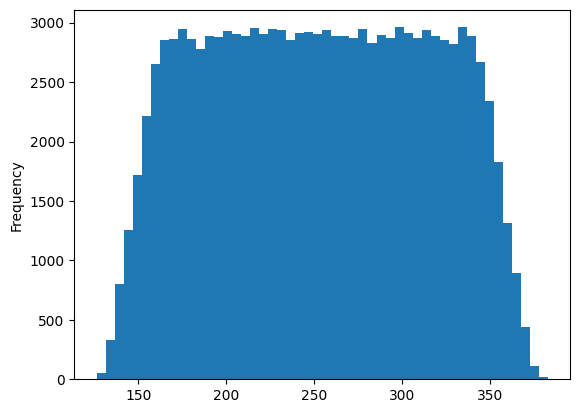

In [153]:
df['ad_revenue_usd'].describe()
df['ad_revenue_usd'].plot.hist(bins=50)

In [157]:
df['engagement_rate'].describe()

count    120000.000000
mean          0.137402
std           0.052162
min           0.025492
25%           0.094966
50%           0.137461
75%           0.179922
max           0.249554
Name: engagement_rate, dtype: float64

In [158]:
df['engagement_rate'] = df['engagement_rate'].round(4)

In [160]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [161]:
pd.set_option('display.max_columns', None)
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,day,month,year,day_of_week,is_weekend,retention_rate,log_subscribers,category_Education,category_Entertainment,category_Gaming,category_Lifestyle,category_Music,category_Tech,device_Desktop,device_Mobile,device_TV,device_Tablet,country_AU,country_CA,country_DE,country_IN,country_UK,country_US,engagement_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.21,2.86,228086,203.178237,24,9,2024,1,0,0.93,12.34,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0.1551
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.75,23.74,736015,140.880508,22,9,2024,6,1,0.06,13.51,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0.0986
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.66,26.20,240534,360.134008,21,11,2024,3,0,0.22,12.39,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0.2145
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.52,11.77,434482,224.638261,28,1,2025,1,0,0.27,12.98,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.1428
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.67,6.64,42030,165.514388,28,4,2025,0,0,0.24,10.65,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0.2361


In [163]:
df.info()

<class 'pandas.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   video_id                120000 non-null  str           
 1   date                    120000 non-null  datetime64[us]
 2   views                   120000 non-null  int64         
 3   likes                   120000 non-null  int64         
 4   comments                120000 non-null  int64         
 5   watch_time_minutes      120000 non-null  float64       
 6   video_length_minutes    120000 non-null  float64       
 7   subscribers             120000 non-null  int64         
 8   ad_revenue_usd          120000 non-null  float64       
 9   day                     120000 non-null  int32         
 10  month                   120000 non-null  int32         
 11  year                    120000 non-null  int32         
 12  day_of_week             120000 non-null  int32

In [ ]:
df.to_csv("cleaned_youtube_data.csv", index=False)